# Coordination-age model and interval visualizations

This notebook visualizes already-saved predictions; it does **not** refit or retune any model. The figures keep three inferential roles separate:

- **Train LOOCV:** model comparison and KRR calibration used during architecture selection.
- **Held-out test:** train-fitted KRR predictions and 95% JK+ intervals.
- **Full-data LOOCV:** final KRR calibration and age-stratified error diagnostics on all 144 subjects.

All PNGs and a figure manifest are saved under `outputs/visualizations/`.


In [1]:
from __future__ import annotations

import json
from pathlib import Path
import warnings

warnings.filterwarnings('ignore', message='pkg_resources is deprecated as an API.*')

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

KRR_NAME = 'RBF Kernel Ridge'
KRR_COLOR = '#0072B2'
OTHER_COLOR = '#A7A9AC'
ACCENT_COLOR = '#D55E00'

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'Data' / 'X.csv').exists() and (candidate / 'outputs' / 'train115_jkplus').exists():
            return candidate
    raise FileNotFoundError('Could not locate the coordination_age project root.')

PROJECT_ROOT = find_project_root(Path.cwd())
TRAIN_OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'train115_jkplus'
FULL_ARTIFACT_DIR = PROJECT_ROOT / 'artifacts' / 'jackknife_plus_krr'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'visualizations'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'font.size': 10,
})
figure_records = []

def save_png(fig, filename, description, sources):
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches='tight')
    figure_records.append({
        'filename': filename,
        'description': description,
        'sources': '; '.join(sources),
    })
    return path

PROJECT_ROOT


PosixPath('/Users/noamchowers/Documents/University/Lab Seminar/coordination_age')

## Load and validate saved predictions

The full-data JK+ residual table stores one OOF KRR prediction per production row. `modeling_input_metadata.json` restores the corresponding subject IDs.


In [2]:
train_predictions = pd.read_csv(TRAIN_OUTPUT_DIR / 'train115_model_selection_oof_predictions.csv')
train_metrics = pd.read_csv(TRAIN_OUTPUT_DIR / 'train115_model_selection_metrics.csv')
test_predictions = pd.read_csv(TRAIN_OUTPUT_DIR / 'train115_jkplus_test29_predictions.csv')
full_residuals = pd.read_csv(FULL_ARTIFACT_DIR / 'coordination_age_krr_jackknife_plus_residuals.csv')
metadata = json.loads((PROJECT_ROOT / 'Data' / 'modeling_input_metadata.json').read_text())
subject_order = np.asarray(metadata['subject_order'], dtype=int)

assert len(train_predictions) == 115 * 6
assert train_predictions.groupby('procedure').size().eq(115).all()
assert train_metrics['procedure'].is_unique and len(train_metrics) == 6
assert len(test_predictions) == 29 and test_predictions['SubjectNumber'].is_unique
assert len(full_residuals) == 144
assert np.array_equal(full_residuals['loo_position'], np.arange(144))
assert len(subject_order) == 144

full_predictions = pd.DataFrame({
    'SubjectNumber': subject_order[full_residuals['loo_position'].to_numpy(int)],
    'chronological_age_years': full_residuals['observed_y'].to_numpy(float),
    'oof_prediction_years': full_residuals['loo_prediction'].to_numpy(float),
    'residual_years': full_residuals['signed_residual'].to_numpy(float),
    'absolute_error_years': full_residuals['absolute_residual'].to_numpy(float),
})

inventory = pd.DataFrame([
    {'role': 'Train LOOCV model comparison', 'subjects': 115, 'procedures': 6, 'has_intervals': False},
    {'role': 'Train-fitted KRR → held-out test', 'subjects': 29, 'procedures': 1, 'has_intervals': True},
    {'role': 'Full-data LOOCV KRR', 'subjects': 144, 'procedures': 1, 'has_intervals': False},
])
display(inventory)


,role,subjects,procedures,has_intervals
0,Train LOOCV model comparison,115,6,False
1,Train-fitted KRR → held-out test,29,1,True
2,Full-data LOOCV KRR,144,1,False


In [3]:
def point_metrics(observed, predicted):
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return {
        'n': len(observed),
        'rmse_years': float(np.sqrt(mean_squared_error(observed, predicted))),
        'mae_years': float(mean_absolute_error(observed, predicted)),
        'r_squared': float(r2_score(observed, predicted)),
    }

train_krr = train_predictions.query('procedure == @KRR_NAME').copy()
summary_metrics = pd.DataFrame([
    {'role': 'Train LOOCV (KRR)', **point_metrics(train_krr['chronological_age_years'], train_krr['oof_prediction_years'])},
    {'role': 'Held-out test (train-fitted KRR)', **point_metrics(test_predictions['chronological_age_years'], test_predictions['predicted_age_years'])},
    {'role': 'Full-data LOOCV (KRR)', **point_metrics(full_predictions['chronological_age_years'], full_predictions['oof_prediction_years'])},
])
summary_metrics['empirical_interval_coverage'] = [np.nan, test_predictions['covered'].mean(), np.nan]
summary_metrics['mean_interval_width_years'] = [np.nan, test_predictions['jkplus_width'].mean(), np.nan]
summary_metrics.to_csv(FIGURE_DIR / 'visualization_summary_metrics.csv', index=False)
display(summary_metrics.round(4))


,role,n,rmse_years,mae_years,r_squared,empirical_interval_coverage,mean_interval_width_years
0,Train LOOCV (KRR),115,1.4215,1.1222,0.8699,NaN,NaN
1,Held-out test (train-fitted KRR),29,1.4035,1.1519,0.8713,1.0,7.2361
2,Full-data LOOCV (KRR),144,1.3862,1.0957,0.8759,NaN,NaN


## Train LOOCV model comparison

The boxplots show subject-level absolute OOF errors—not per-subject RMSE. Procedures are ordered by their aggregate OOF RMSE, the prespecified selection criterion.


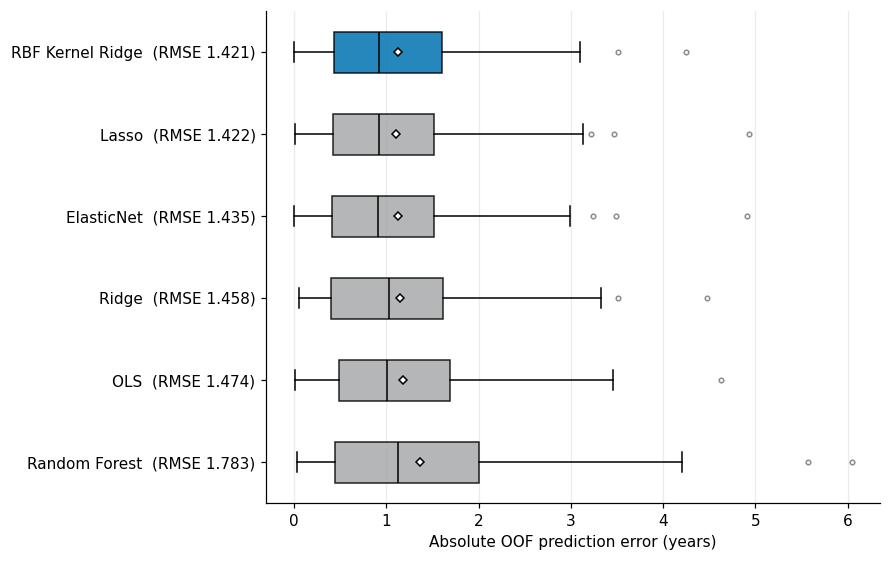

In [4]:
comparison = train_predictions.copy()
comparison['absolute_error_years'] = (comparison['chronological_age_years'] - comparison['oof_prediction_years']).abs()
ordered_procedures = train_metrics.sort_values('rmse_rank')['procedure'].tolist()
rmse_lookup = train_metrics.set_index('procedure')['rmse_years']
box_data = [comparison.loc[comparison['procedure'].eq(name), 'absolute_error_years'] for name in ordered_procedures]
labels = [f'{name}  (RMSE {rmse_lookup[name]:.3f})' for name in ordered_procedures]

fig, ax = plt.subplots(figsize=(8.2, 5.2))
boxes = ax.boxplot(box_data[::-1], tick_labels=labels[::-1], vert=False, patch_artist=True, showmeans=True,
                   meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize': 4},
                   medianprops={'color': 'black'}, flierprops={'marker': '.', 'alpha': 0.45})
for patch, name in zip(boxes['boxes'], ordered_procedures[::-1]):
    patch.set_facecolor(KRR_COLOR if name == KRR_NAME else OTHER_COLOR)
    patch.set_alpha(0.85)
ax.set_xlabel('Absolute OOF prediction error (years)')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
save_png(fig, 'figure_1_train_loocv_model_comparison.png',
         'Absolute train-set OOF error distributions, ordered by aggregate RMSE.',
         ['train115_model_selection_oof_predictions.csv', 'train115_model_selection_metrics.csv'])
plt.show()


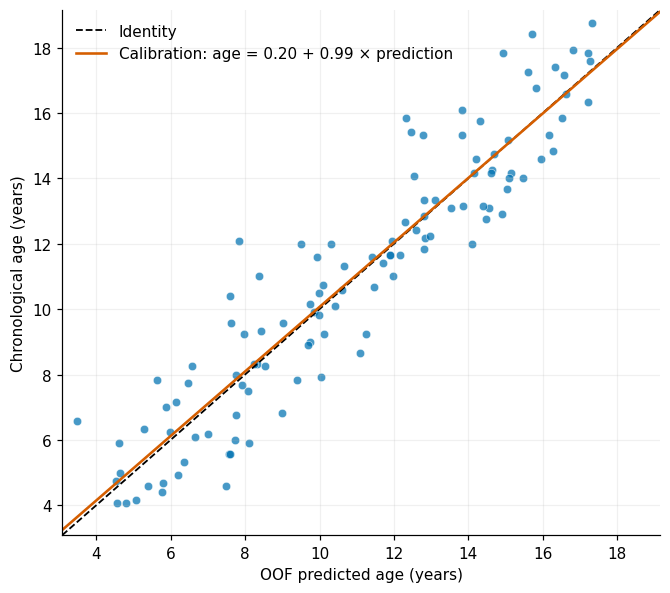

In [5]:
observed = train_krr['chronological_age_years'].to_numpy(float)
predicted = train_krr['oof_prediction_years'].to_numpy(float)
slope, intercept = np.polyfit(predicted, observed, 1)
limits = [min(observed.min(), predicted.min()) - 0.4, max(observed.max(), predicted.max()) + 0.4]
grid = np.linspace(*limits, 100)

fig, ax = plt.subplots(figsize=(6.2, 5.5))
ax.scatter(predicted, observed, s=30, color=KRR_COLOR, alpha=0.72, edgecolor='white', linewidth=0.4)
ax.plot(limits, limits, '--', color='black', lw=1.2, label='Identity')
ax.plot(grid, intercept + slope * grid, color=ACCENT_COLOR, lw=1.7,
        label=f'Calibration: age = {intercept:.2f} + {slope:.2f} × prediction')
ax.set(xlim=limits, ylim=limits, xlabel='OOF predicted age (years)', ylabel='Chronological age (years)')
ax.legend(frameon=False, loc='upper left')
ax.grid(alpha=0.18)
fig.tight_layout()
save_png(fig, 'figure_2_train_loocv_krr_calibration.png',
         'Chronological versus KRR OOF-predicted age on the train set.',
         ['train115_model_selection_oof_predictions.csv'])
plt.show()


## Held-out test predictions and JK+ intervals

These are the only saved intervals suitable for an out-of-sample interval audit: every prediction, residual score, and endpoint was produced from the 115 training subjects. Because the test outcomes were inspected earlier in the project, empirical coverage remains a post-hoc diagnostic.


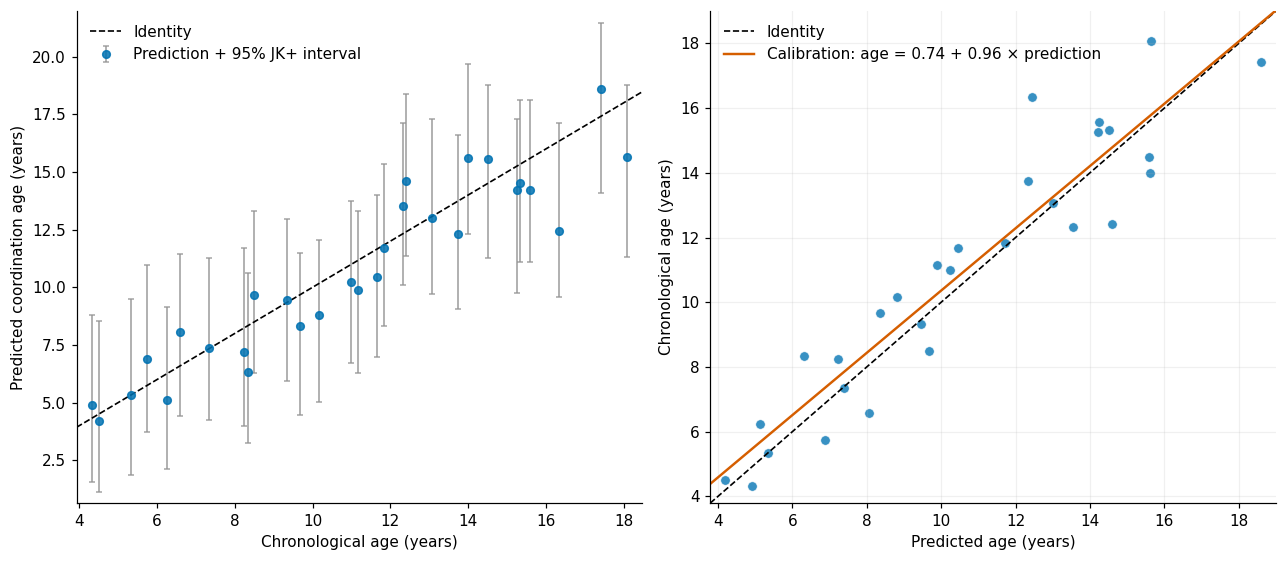

In [6]:
test_plot = test_predictions.sort_values('chronological_age_years').copy()
lower_error = test_plot['predicted_age_years'] - test_plot['jkplus_lower']
upper_error = test_plot['jkplus_upper'] - test_plot['predicted_age_years']
x_limits = [test_plot['chronological_age_years'].min() - 0.4, test_plot['chronological_age_years'].max() + 0.4]
y_limits = [min(test_plot['jkplus_lower'].min() - 0.5, x_limits[0]), max(test_plot['jkplus_upper'].max() + 0.5, x_limits[1])]
coverage = test_plot['covered'].mean()

predicted = test_plot['predicted_age_years'].to_numpy(float)
observed = test_plot['chronological_age_years'].to_numpy(float)
calibration_slope, calibration_intercept = np.polyfit(predicted, observed, 1)
calibration_limits = [min(predicted.min(), observed.min()) - 0.4, max(predicted.max(), observed.max()) + 0.4]
calibration_grid = np.linspace(*calibration_limits, 100)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.2))
ax = axes[0]
ax.errorbar(test_plot['chronological_age_years'], test_plot['predicted_age_years'],
            yerr=np.vstack([lower_error, upper_error]), fmt='o', ms=5, color=KRR_COLOR,
            ecolor='0.58', elinewidth=1.1, capsize=2, alpha=0.85, label='Prediction + 95% JK+ interval')
ax.plot(x_limits, x_limits, '--', color='black', lw=1.1, label='Identity')
ax.set(xlim=x_limits, ylim=y_limits, xlabel='Chronological age (years)', ylabel='Predicted coordination age (years)')
ax.legend(frameon=False)

ax = axes[1]
ax.scatter(predicted, observed, s=38, color=KRR_COLOR, alpha=0.78, edgecolor='white', linewidth=0.4)
ax.plot(calibration_limits, calibration_limits, '--', color='black', lw=1.1, label='Identity')
ax.plot(calibration_grid, calibration_intercept + calibration_slope * calibration_grid, color=ACCENT_COLOR, lw=1.6,
        label=f'Calibration: age = {calibration_intercept:.2f} + {calibration_slope:.2f} × prediction')
ax.set(xlim=calibration_limits, ylim=calibration_limits, xlabel='Predicted age (years)', ylabel='Chronological age (years)')
ax.legend(frameon=False)
ax.grid(alpha=0.18)

fig.tight_layout()
save_png(fig, 'figure_3_test_jkplus_interval_diagnostics.png',
         'Held-out test predictions, 95% JK+ intervals, and train-to-test calibration.',
         ['train115_jkplus_test29_predictions.csv'])
plt.show()


## Full-data LOOCV KRR diagnostics

These 144 OOF predictions diagnose the finalized KRR learning procedure after all subjects became training data. They are not a fresh external test estimate and are not used to reopen architecture selection.


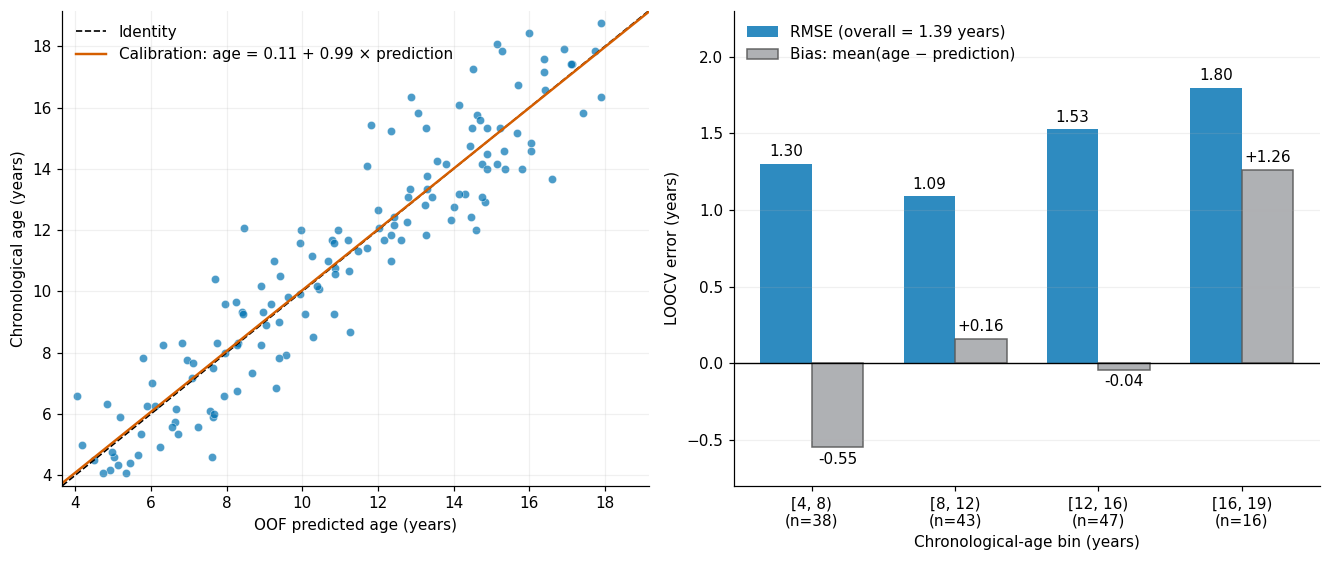

In [7]:
observed = full_predictions['chronological_age_years'].to_numpy(float)
predicted = full_predictions['oof_prediction_years'].to_numpy(float)
slope, intercept = np.polyfit(predicted, observed, 1)
limits = [min(observed.min(), predicted.min()) - 0.4, max(observed.max(), predicted.max()) + 0.4]
grid = np.linspace(*limits, 100)
assert observed.min() >= 4 and observed.max() < 19
age_bin_frame = pd.DataFrame({
    'age_bin': pd.cut(observed, bins=[4, 8, 12, 16, 19],
                      labels=['[4, 8)', '[8, 12)', '[12, 16)', '[16, 19)'],
                      right=False, include_lowest=True),
    'squared_error': (observed - predicted) ** 2,
    'residual': observed - predicted,
})
age_bin_rmse = (age_bin_frame.groupby('age_bin', observed=True, sort=True)
                .agg(n=('squared_error', 'size'),
                     rmse_years=('squared_error', lambda values: np.sqrt(values.mean())),
                     bias_years=('residual', 'mean'))
                .reset_index())
overall_rmse = np.sqrt(np.mean((observed - predicted) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.2))
ax = axes[0]
ax.scatter(predicted, observed, s=29, color=KRR_COLOR, alpha=0.7, edgecolor='white', linewidth=0.35)
ax.plot(limits, limits, '--', color='black', lw=1.1, label='Identity')
ax.plot(grid, intercept + slope * grid, color=ACCENT_COLOR, lw=1.6,
        label=f'Calibration: age = {intercept:.2f} + {slope:.2f} × prediction')
ax.set(xlim=limits, ylim=limits, xlabel='OOF predicted age (years)', ylabel='Chronological age (years)')
ax.legend(frameon=False)
ax.grid(alpha=0.18)

ax = axes[1]
positions = np.arange(len(age_bin_rmse))
bar_width = 0.36
rmse_bars = ax.bar(positions - bar_width / 2, age_bin_rmse['rmse_years'], width=bar_width,
                   color=KRR_COLOR, alpha=0.82,
                   label=f'RMSE (overall = {overall_rmse:.2f} years)')
bias_bars = ax.bar(positions + bar_width / 2, age_bin_rmse['bias_years'], width=bar_width,
                   color=OTHER_COLOR, edgecolor='0.35', alpha=0.9,
                   label='Bias: mean(age − prediction)')
ax.axhline(0, color='black', lw=0.9)
ax.bar_label(rmse_bars, labels=[f'{rmse:.2f}' for rmse in age_bin_rmse['rmse_years']], padding=3)
ax.bar_label(bias_bars, labels=[f'{bias:+.2f}' for bias in age_bin_rmse['bias_years']], padding=3)
age_bin_tick_labels = [f'{age_bin}\n(n={n_subjects})'
                       for age_bin, n_subjects in zip(age_bin_rmse['age_bin'].astype(str), age_bin_rmse['n'])]
ax.set_xticks(positions, age_bin_tick_labels)
ax.set(xlabel='Chronological-age bin (years)', ylabel='LOOCV error (years)',
       ylim=(min(-0.8, age_bin_rmse['bias_years'].min() - 0.2),
             age_bin_rmse['rmse_years'].max() + 0.5))
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.18)

fig.tight_layout()
save_png(fig, 'figure_4_full_data_loocv_krr_diagnostics.png',
         'Calibration plus chronological-age-bin RMSE and bias for full-data KRR OOF predictions.',
         ['coordination_age_krr_jackknife_plus_residuals.csv', 'modeling_input_metadata.json'])
plt.show()


## Saved figure manifest


In [8]:
figure_manifest = pd.DataFrame(figure_records)
figure_manifest.to_csv(FIGURE_DIR / 'figure_manifest.csv', index=False)
display(figure_manifest)


,filename,description,sources
0,figure_1_train_loocv_model_comparison.png,"Absolute train-set OOF error distributions, or...",train115_model_selection_oof_predictions.csv; ...
1,figure_2_train_loocv_krr_calibration.png,Chronological versus KRR OOF-predicted age on ...,train115_model_selection_oof_predictions.csv
2,figure_3_test_jkplus_interval_diagnostics.png,"Held-out test predictions, 95% JK+ intervals, ...",train115_jkplus_test29_predictions.csv
3,figure_4_full_data_loocv_krr_diagnostics.png,Calibration plus chronological-age-bin RMSE an...,coordination_age_krr_jackknife_plus_residuals....


## Interpretation guardrails

- Use the **train LOOCV** plots to document architecture selection and comparative behavior.
- Use the **test** plots for point-prediction and interval diagnostics, while labeling them as post-hoc because these outcomes were accessed earlier.
- Use the **full-data LOOCV** plots to describe the final KRR procedure after refitting on the complete cohort—not as independent external validation.
- Do not estimate interval coverage from naïve intervals evaluated on the same train/full subjects used for JK+ calibration; only the saved test intervals are shown here.
